# Basic statistics su `WineQT.csv` duomenimis

Bazinė statistinė analizė su `pandas`, `numpy`, `matplotlib` ir `scipy.stats`:
- duomenų peržiūra ir santrauka
- skirstiniai (histogramos), ryšiai (scatterplot)
- koreliacijos ir koreliacijų matrica
- outlier (išskirčių) aptikimas
- normalumo testai: **Shapiro-Wilk**, **D’Agostino K² (`normaltest`)**, **Anderson-Darling**
- koreliacijos testai: **Pearson**, **Spearman**, **Kendall** 


# Dataset

https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

In [4]:
# Bibliotekos (standartinis rinkinys)
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, normaltest, pearsonr, spearmanr, kendalltau, anderson

# Patogesniam vaizdų rodymui
plt.rcParams["figure.figsize"] = (8, 4)


## 1) Duomenų įkėlimas



In [5]:
df = pd.read_csv(r"files/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 2) Greita peržiūra ir pagrindinė santrauka

In [6]:
# Struktūra ir pirmos eilutės
display(df.head())
print("Eilučių skaičius:", df.shape[0])
print("Stulpelių skaičius:", df.shape[1])


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Eilučių skaičius: 1143
Stulpelių skaičius: 13


In [7]:
# Trūkstamos reikšmės (
df.isna().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [8]:
# Tipai ir bazinė statistika
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [9]:
# Skaitinių stulpelių statistika
# include='all' dažnai sukuria daug informacijos, bet pradedantiesiems pakanka skaitinių
df.describe().T.round()


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.0,2.0,5.0,7.0,8.0,9.0,16.0
volatile acidity,1143.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0
citric acid,1143.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
residual sugar,1143.0,3.0,1.0,1.0,2.0,2.0,3.0,16.0
chlorides,1143.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
free sulfur dioxide,1143.0,16.0,10.0,1.0,7.0,13.0,21.0,68.0
total sulfur dioxide,1143.0,46.0,33.0,6.0,21.0,37.0,61.0,289.0
density,1143.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
pH,1143.0,3.0,0.0,3.0,3.0,3.0,3.0,4.0
sulphates,1143.0,1.0,0.0,0.0,1.0,1.0,1.0,2.0


## 3) Skirstiniai: histogramos

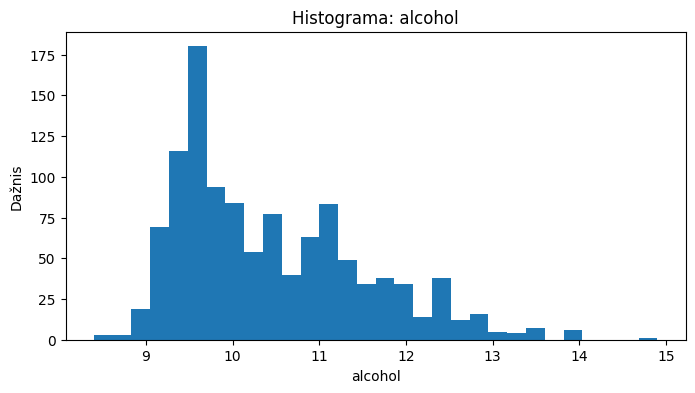

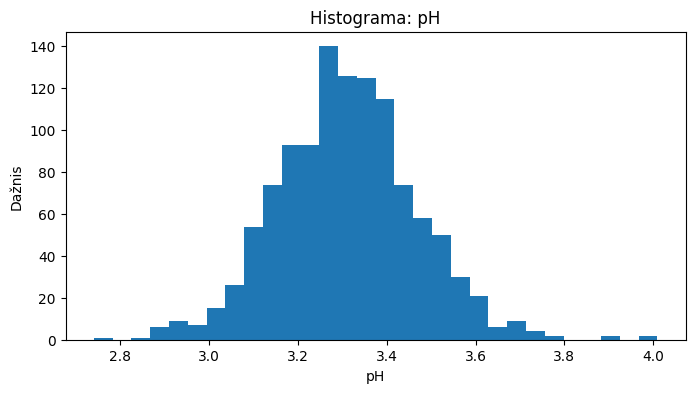

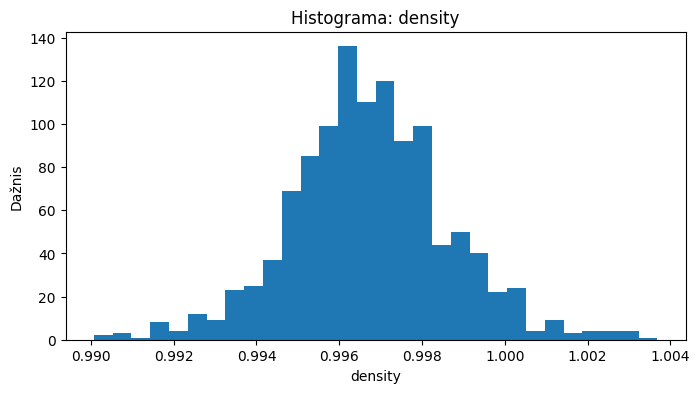

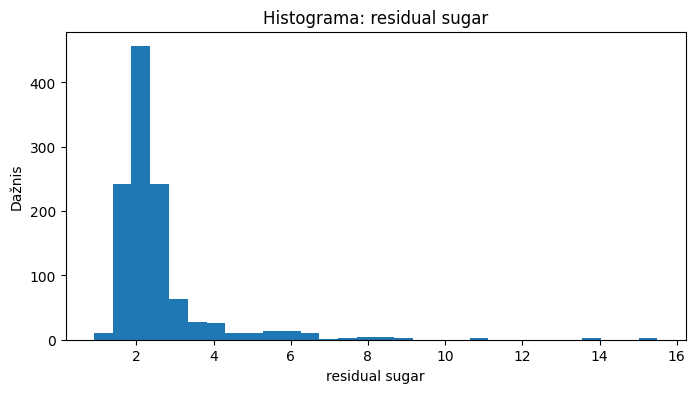

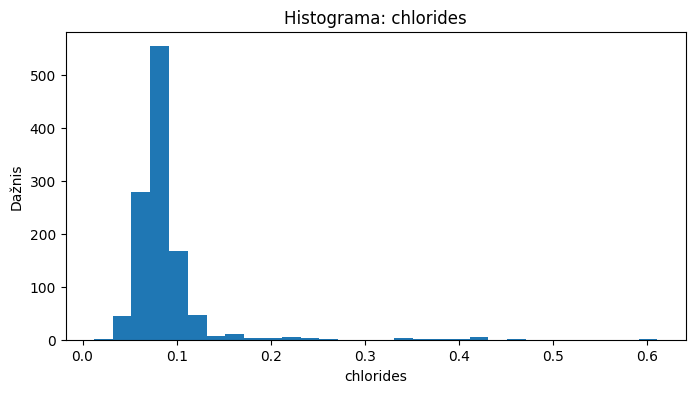

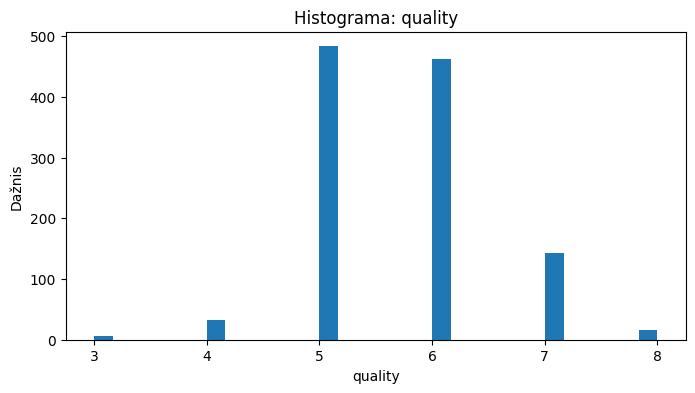

In [10]:
# Pasirenkami keli stulpeliai vizualizacijoms (paprasta ir aišku)
cols = ["alcohol", "pH", "density", "residual sugar", "chlorides", "quality"]

for c in cols:
    plt.figure()
    plt.hist(df[c], bins=30)
    plt.title(f"Histograma: {c}")
    plt.xlabel(c)
    plt.ylabel("Dažnis")
    plt.show()


Geroji praktika:
- pradėti nuo kelių svarbiausių kintamųjų, o ne iškart braižyti visus 12–15
- naudoti aiškius pavadinimus ir ašių etiketes
- lyginti histogramos formą su realia prasme (pvz., `quality` yra diskretus įvertinimas)

Dažna klaida: histogramos interpretavimas kaip „normalus skirstinys“ vien dėl to, kad forma „panaši į varpą“.
Normalumą tiksliau įvertina ir vizualūs metodai (Q-Q), ir testai (toliau).


## 4) Ryšiai tarp kintamųjų: scatterplot

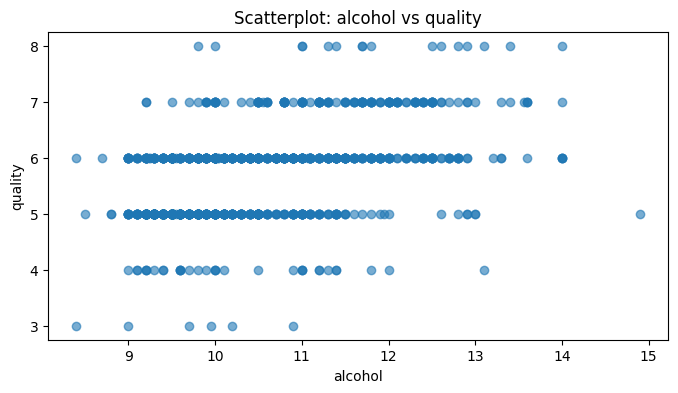

In [11]:
# Paprastas ir dažnas pavyzdys: alkoholis vs kokybė
plt.figure()
plt.scatter(df["alcohol"], df["quality"], alpha=0.6)
plt.title("Scatterplot: alcohol vs quality")
plt.xlabel("alcohol")
plt.ylabel("quality")
plt.show()


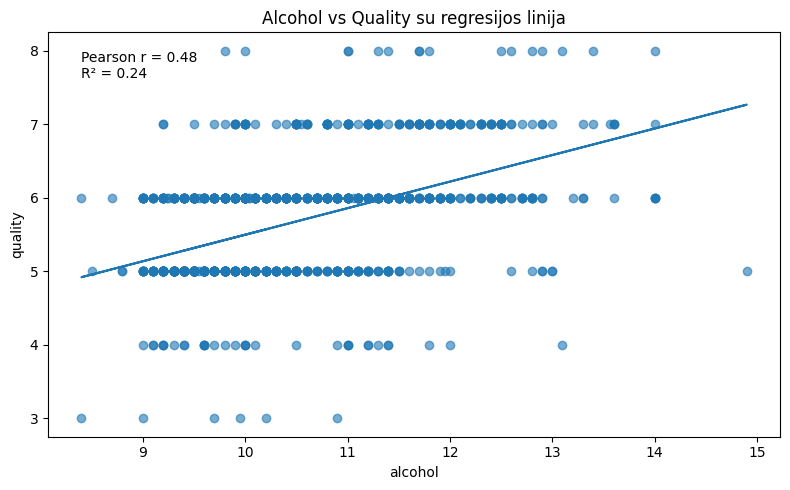

In [12]:
#reggresion line

# Duomenys
x = df["alcohol"]
y = df["quality"]

# 1) Pearson koreliacija
r, p_value = pearsonr(x, y)

# 2) Linijinė regresija (y = a*x + b)
coef = np.polyfit(x, y, 1)
reg_line = np.poly1d(coef)

# 3) R² (paaiškintos dispersijos dalis)
y_pred = reg_line(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - ss_res / ss_tot

# 4) Vizualizacija
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6)
plt.plot(x, reg_line(x))

plt.title("Alcohol vs Quality su regresijos linija")
plt.xlabel("alcohol")
plt.ylabel("quality")

# Tekstas grafike
plt.text(
    x.min(),
    y.max(),
    f"Pearson r = {r:.2f}\nR² = {r_squared:.2f}",
    verticalalignment="top"
)

plt.tight_layout()
plt.show()


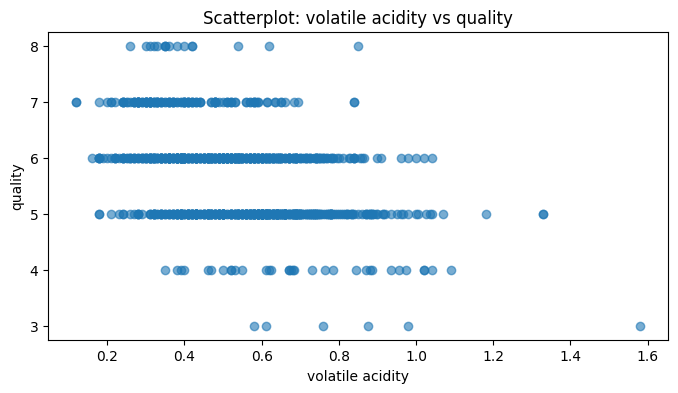

In [13]:
# Kitas dažnas ryšys: volatile acidity vs quality
plt.figure()
plt.scatter(df["volatile acidity"], df["quality"], alpha=0.6)
plt.title("Scatterplot: volatile acidity vs quality")
plt.xlabel("volatile acidity")
plt.ylabel("quality")
plt.show()


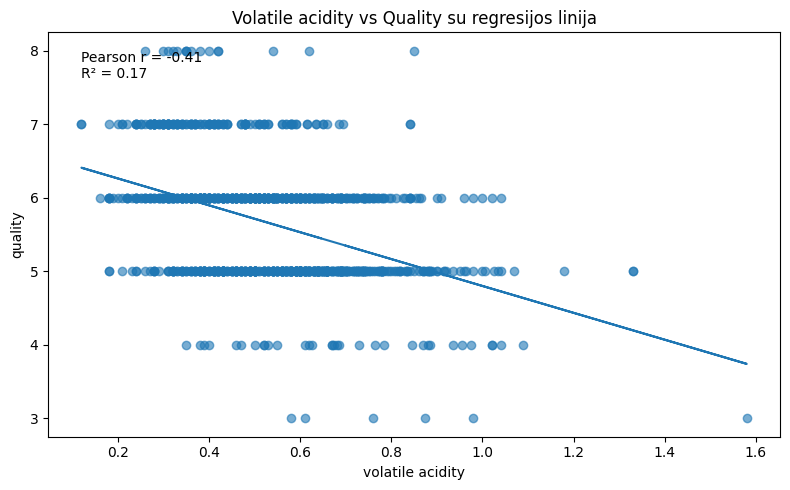

In [14]:
# regression line

# Duomenys
x = df["volatile acidity"]
y = df["quality"]

# 1) Pearson koreliacija
r, p_value = pearsonr(x, y)

# 2) Linijinė regresija (y = a*x + b)
coef = np.polyfit(x, y, 1)
reg_line = np.poly1d(coef)

# 3) R²
y_pred = reg_line(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - ss_res / ss_tot

# 4) Vizualizacija
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6)
plt.plot(x, reg_line(x))

plt.title("Volatile acidity vs Quality su regresijos linija")
plt.xlabel("volatile acidity")
plt.ylabel("quality")

plt.text(
    x.min(),
    y.max(),
    f"Pearson r = {r:.2f}\nR² = {r_squared:.2f}",
    verticalalignment="top"
)

plt.tight_layout()
plt.show()


## 5) Koreliacijos

In [15]:
# Pearson koreliacijų matrica (greita santrauka)
corr_pearson = df.drop(columns=["Id"], errors="ignore").corr(method="pearson")
corr_pearson


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710


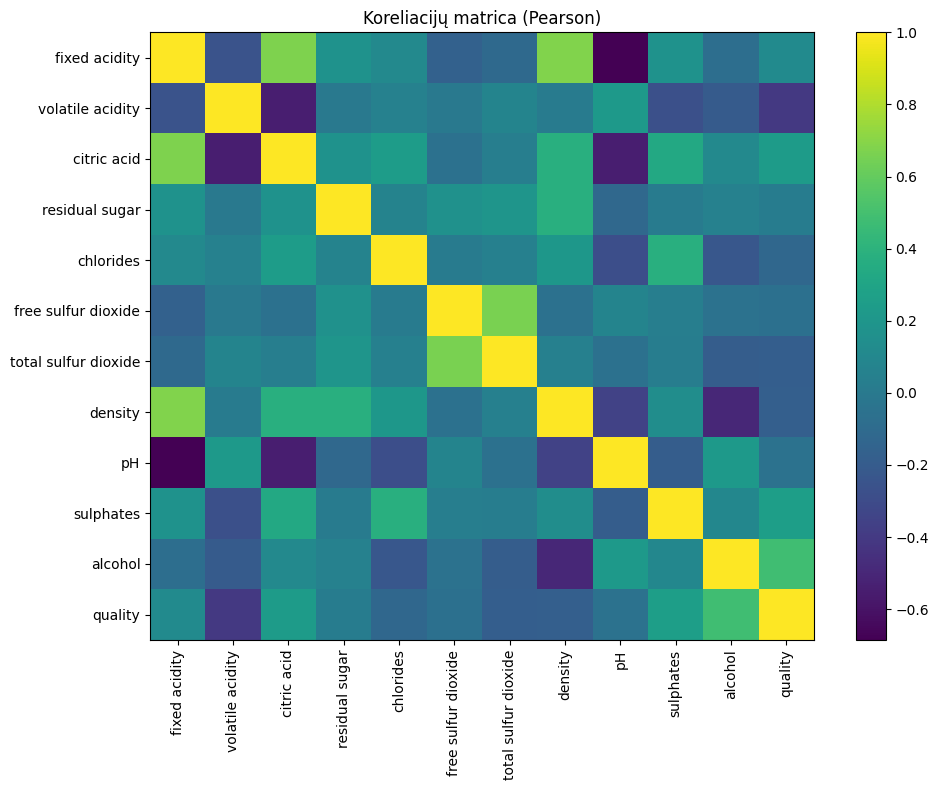

In [16]:
# Koreliacijų matricos vizualizacija (be seaborn)
plt.figure(figsize=(10, 8))
plt.imshow(corr_pearson, aspect="auto")
plt.title("Koreliacijų matrica (Pearson)")
plt.xticks(range(len(corr_pearson.columns)), corr_pearson.columns, rotation=90)
plt.yticks(range(len(corr_pearson.columns)), corr_pearson.columns)
plt.colorbar()
plt.tight_layout()
plt.show()


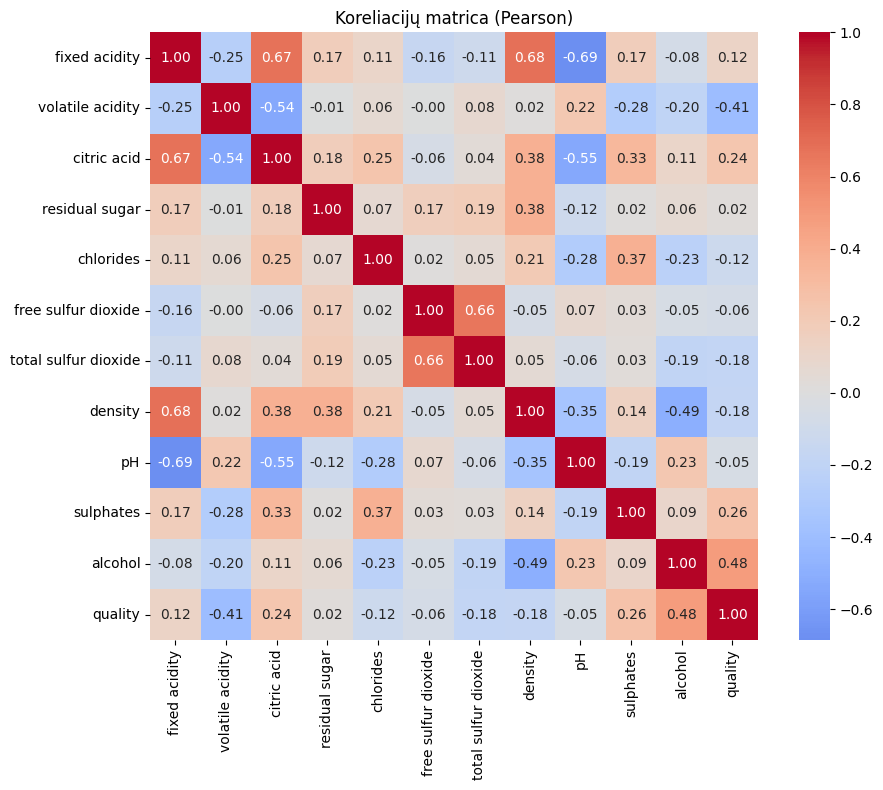

In [17]:

# Koreliacijų matricos vizualizacija (su seaborn)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_pearson,
    annot=True,        # rodo koreliacijos reikšmes
    fmt=".2f",         # 2 skaitmenys po kablelio
    cmap="coolwarm",   # spalvų skalė
    center=0,          # 0 – neutralus taškas
    square=True
)

plt.title("Koreliacijų matrica (Pearson)")
plt.tight_layout()
plt.show()


### 5.2 Koreliacijos testai dviem kintamiesiems

In [18]:
# Funkcija, kuri grąžina Pearson, Spearman ir Kendall testus
def corr_tests(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    # Pearson
    r_p, p_p = pearsonr(x, y)
    # Spearman
    r_s, p_s = spearmanr(x, y)
    # Kendall
    r_k, p_k = kendalltau(x, y)

    return pd.DataFrame(
        {
            "method": ["pearson", "spearman", "kendall"],
            "statistic": [r_p, r_s, r_k],
            "p_value": [p_p, p_s, p_k],
        }
    )

# Pavyzdys: alcohol ir quality
corr_tests(df["alcohol"], df["quality"])


,method,statistic,p_value
0,pearson,0.484866,1.924653e-68
1,spearman,0.495439,7.850043e-72
2,kendall,0.396085,1.805063e-65


## 6) Outlier (išskirtys)

In [19]:
# IQR metodas (paprastas ir dažnas)
def iqr_outliers(series, k=1.5):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (s < lower) | (s > upper)
    return mask.sum(), lower, upper

outlier_summary = []
numeric_cols = df.select_dtypes(include="number").columns.tolist()
if "Id" in numeric_cols:
    numeric_cols.remove("Id")

for c in numeric_cols:
    n_out, lo, hi = iqr_outliers(df[c])
    outlier_summary.append([c, n_out, lo, hi])

pd.DataFrame(outlier_summary, columns=["column", "outliers_iqr_count", "lower_bound", "upper_bound"])   .sort_values("outliers_iqr_count", ascending=False)


,column,outliers_iqr_count,lower_bound,upper_bound
3,residual sugar,110,0.850000,3.650000
4,chlorides,77,0.040000,0.120000
0,fixed acidity,44,4.100000,12.100000
9,sulphates,43,0.280000,1.000000
6,total sulfur dioxide,40,-39.000000,121.000000
7,density,36,0.992157,1.001257
11,quality,22,3.500000,7.500000
8,pH,20,2.912500,3.692500
5,free sulfur dioxide,18,-14.000000,42.000000
1,volatile acidity,14,0.021250,1.011250


C:\Users\stasy\AppData\Local\Temp\ipykernel_17120\2920948333.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


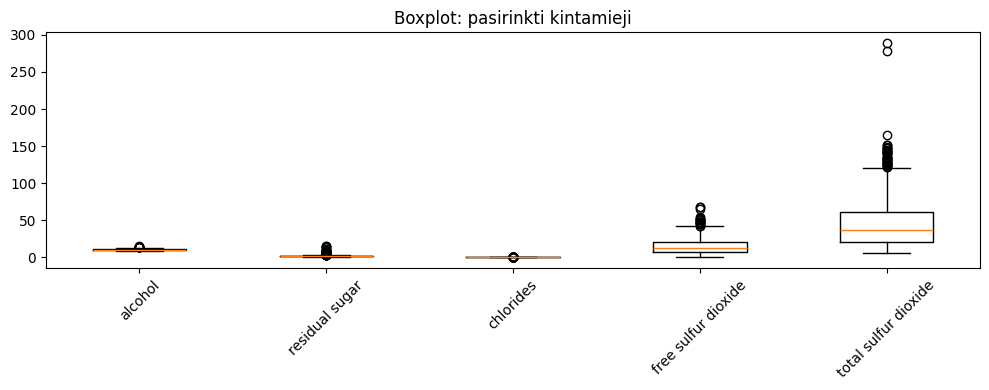

In [20]:
# Boxplot keliems kintamiesiems (aišku, kas turi ilgus "ūsus") 

cols_box = ["alcohol", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide"]

plt.figure(figsize=(10, 4))
plt.boxplot(
    [df[c].dropna() for c in cols_box],
    labels=cols_box,
    vert=True
)
plt.title("Boxplot: pasirinkti kintamieji")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 7) Normalumo įvertinimas

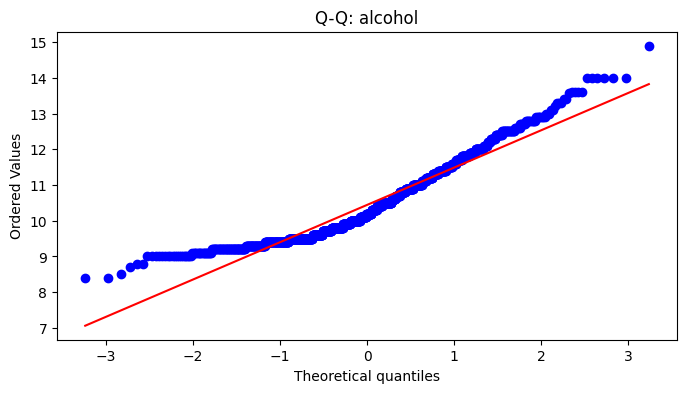

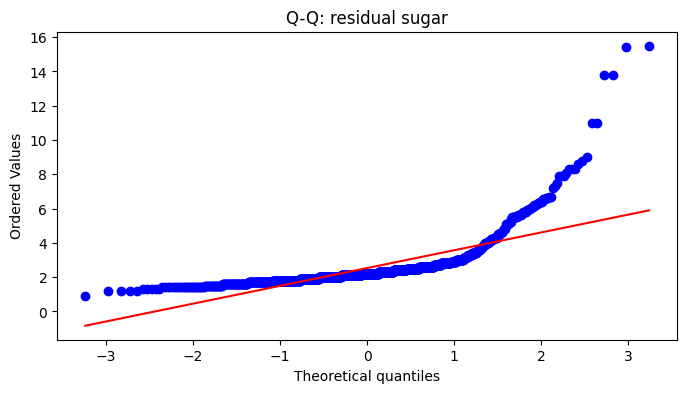

In [21]:
# Q-Q grafikas (vizualus normalumo patikrinimas)
def qq_plot(series, title):
    x = series.dropna().values
    plt.figure()
    stats.probplot(x, dist="norm", plot=plt)
    plt.title(title)
    plt.show()

qq_plot(df["alcohol"], "Q-Q: alcohol")
qq_plot(df["residual sugar"], "Q-Q: residual sugar")


### 7.1 Shapiro-Wilk testas

In [22]:
# Shapiro rekomenduojamas mažesnėms imtims, bet naudojamas ir edukacijai.
# Jei N labai didelis, galima paimti atsitiktinį mėginį, kad testas būtų stabilesnis ir greitesnis.

def shapiro_test(series, sample_n=5000, random_state=42):
    x = series.dropna()
    if len(x) > sample_n:
        x = x.sample(sample_n, random_state=random_state)
    stat, p = shapiro(x)
    return stat, p, len(x)

for c in ["alcohol", "pH", "density"]:
    stat, p, n = shapiro_test(df[c])
    print(f"{c:>10} | n={n:>5} | Shapiro stat={stat:.4f} | p={p:.4g}")


   alcohol | n= 1143 | Shapiro stat=0.9289 | p=7.517e-23
        pH | n= 1143 | Shapiro stat=0.9921 | p=8.673e-06
   density | n= 1143 | Shapiro stat=0.9907 | p=1.246e-06


### 7.2 D’Agostino K² (`normaltest`)

In [23]:
# normaltest reikalauja pakankamai didelės imties (paprastai N >= 8)
def dagostino_test(series):
    x = series.dropna().values
    stat, p = normaltest(x)
    return stat, p, len(x)

for c in ["alcohol", "pH", "density"]:
    stat, p, n = dagostino_test(df[c])
    print(f"{c:>10} | n={n:>5} | K2 stat={stat:.4f} | p={p:.4g}")


   alcohol | n= 1143 | K2 stat=111.5674 | p=5.936e-25
        pH | n= 1143 | K2 stat=30.2719 | p=2.67e-07
   density | n= 1143 | K2 stat=21.8816 | p=1.772e-05


### 7.3 Anderson-Darling testas

In [24]:
# Anderson grąžina test statistic ir kritines reikšmes skirtingiems reikšmingumo lygiams
def anderson_test(series):
    x = series.dropna().values
    res = anderson(x, dist="norm")
    out = pd.DataFrame(
        {"significance_level_%": res.significance_level, "critical_value": res.critical_values}
    )
    return res.statistic, out, len(x)

stat, table, n = anderson_test(df["alcohol"])
print(f"alcohol | n={n} | Anderson stat={stat:.4f}")
display(table)


alcohol | n=1143 | Anderson stat=25.1559


C:\Users\stasy\AppData\Local\Temp\ipykernel_17120\1182759638.py:4: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = anderson(x, dist="norm")


,significance_level_%,critical_value
0,15.0,0.561
1,10.0,0.631
2,5.0,0.752
3,2.5,0.872
4,1.0,1.034
